## 4. Metode & Eksperimen

#### 4.1 KNN

`Konteks` : Cell ini berfungsi untuk mencari kombinasi parameter terbaik pada algoritma K-Nearest Neighbors (KNN) menggunakan metode pencarian menyeluruh (Grid Search) dan pengujian silang berlipat (Stratified K-Fold) berdasarkan skor F1-Macro tertinggi.

- `skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`` `: Berfungsi untuk membagi data menjadi 5 lipatan (folds) secara acak dengan menjaga persentase kelas target agar tetap seimbang di setiap lipatannya.

- `knn = KNeighborsClassifier()`` `: Berfungsi untuk membuat objek model dasar dari algoritma K-Nearest Neighbors sebelum ditingkatkan performanya.

- `param_grid_knn = { ... }`` `: Berfungsi untuk menentukan daftar pilihan parameter (jumlah tetangga, pembobotan jarak, dan rumus jarak geometri) yang akan diuji coba kecocokannya oleh program.

- `grid_search_knn = GridSearchCV(...)`` `: Berfungsi untuk membuat objek pencarian otomatis yang akan menguji semua kombinasi parameter di dalam param_grid_knn menggunakan metode validasi skf dan penilaian f1_macro.

- `grid_search_knn.fit(X_scaled, y)`` `: Berfungsi untuk menjalankan proses pelatihan dan pencarian kombinasi parameter terbaik menggunakan data fitur yang sudah disetarakan ukurannya (X_scaled) dan target y.

- `print("Hyperparameter Terbaik KNN:", grid_search_knn.best_params_)`` `: Berfungsi untuk menampilkan kombinasi parameter paling sesuai yang menghasilkan akurasi/skor tertinggi selama proses pengujian.

- `print("Skor F1-Macro Validasi (K-Fold): ...")`` `: Berfungsi untuk menampilkan rata-rata skor performa F1-Macro terbaik yang di dapat model dalam bentuk persentase (%).

- `best_knn_model = grid_search_knn.best_estimator_`` `: Berfungsi untuk mengunci dan menyimpan model KNN dengan parameter terbaik ke dalam variabel best_knn_model agar dapat digunakan untuk prediksi.

In [14]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("=== TRAINING K-NEAREST NEIGHBORS (KNN) ===")
knn = KNeighborsClassifier()

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    estimator=knn, 
    param_grid=param_grid_knn, 
    cv=skf, 
    scoring='f1_macro',
    n_jobs=-1  
)

# PAKAI DATA UTUH DI SINI
grid_search_knn.fit(X_scaled, y)

print("\n=== HASIL OPTIMASI KNN ===")
print("Hyperparameter Terbaik KNN:", grid_search_knn.best_params_)
print("Skor F1-Macro Validasi (K-Fold): {:.2f}%".format(grid_search_knn.best_score_ * 100))

best_knn_model = grid_search_knn.best_estimator_

=== TRAINING K-NEAREST NEIGHBORS (KNN) ===

=== HASIL OPTIMASI KNN ===
Hyperparameter Terbaik KNN: {'metric': 'manhattan', 'n_neighbors': 7, 'weights': 'distance'}
Skor F1-Macro Validasi (K-Fold): 87.39%


####  Justifikasi Rentang Parameter dan Dinamika Pencarian Grid Search KNN

Penentuan rentang nilai (grid values) hyperparameter untuk algoritma K-Nearest Neighbors (KNN) didasarkan pada pertimbangan teoretis geometris berikut untuk menemukan model dengan kemampuan terbaik (menghindari underfitting dan overfitting):

- `n_neighbors`: `[3, 5, 7, 9, 11, 13, 15]`
Rentang nilai ganjil ini diuji untuk mencari titik paling seimbang (sweet spot) bagi model KNN. Nilai rendah seperti 3 membuat model terlalu sensitif terhadap data pencilan (noise), sedangkan nilai tinggi seperti 15 bisa membuat keputusan model terlalu kabur (underfitting). Hasil Grid Search membuktikan bahwa $K=7$ adalah jumlah tetangga paling optimal untuk memprediksi tingkat stres mahasiswa secara stabil.

 - `weights`: `['uniform', 'distance']`
  Dua skema ini diuji untuk membandingkan pengaruh jarak. Pilihan distance keluar sebagai pemenang karena model memberikan bobot lebih besar kepada tetangga yang posisinya paling dekat secara geometri, sehingga tebakan model jadi lebih sensitif dan akurat.


- `metric`: `['euclidean', 'manhattan']
  Pengujian metrik jarak ini dilakukan untuk melihat cara ukur terbaik di ruang dimensi data. Jarak manhattan terpilih karena terbukti lebih tangguh dan akurat dalam membaca pola penyebaran indikator psikologis mahasiswa dibanding euclidean.

- `Transparansi Eksplorasi Proses Pencarian Parameter` :

    - Kombinasi Eksperimen: Pencarian otomatis ini menyilangkan 7 variasi jumlah tetangga, 2 skema bobot, dan 2 metrik jarak, sehingga menghasilkan 28 arsitektur model KNN yang berbeda.

    - Mekanisme Validasi: Menggunakan skema 5-Fold Cross Validation, setiap kombinasi dilatih 5 kali lipat secara bergantian. Total ada 140 kali iterasi latihan di balik layar untuk memastikan hasil yang objektif.

    - Hasil Akhir: Model KNN terbaik mengunci parameter {metric: 'manhattan', n_neighbors: 7, weights: 'distance'} dan berhasil mencatatkan skor Macro F1-Score sebesar 87.39%.

#### 4.2 TREE

`Konteks` : Cell ini berfungsi untuk mencari kombinasi parameter paling optimal pada algoritma Decision Tree Classifier menggunakan metode pengujian menyeluruh (Grid Search) untuk mencegah model dari masalah overfitting atau underfitting.

- `dt = DecisionTreeClassifier(random_state=42)`` `: Berfungsi untuk membuat objek model dasar dari algoritma Decision Tree dengan menetapkan nilai acak (random_state=42) agar hasil percabangannya konsisten setiap kali dijalankan.

- `param_grid_dt = { ... }`` `: Berfungsi untuk menentukan daftar pilihan parameter pohon keputusan (kriteria percabangan, batas kedalaman pohon, dan syarat minimal sampel per cabang) yang akan diuji kinerjanya.

- `grid_search_dt = GridSearchCV(...)`` `: Berfungsi untuk membangun sistem pencarian otomatis yang menguji semua kombinasi parameter di dalam param_grid_dt menggunakan validasi silang berlipat (cv=skf) dan penilaian berdasarkan skor F1-Macro.

- `grid_search_dt.fit(X_scaled, y)`` `: Berfungsi untuk memulai proses pelatihan model dan pencarian parameter terbaik menggunakan data input terstandarisasi (X_scaled) dan target label y.

- `print("Hyperparameter Terbaik Decision Tree:", grid_search_dt.best_params_)`` `: Berfungsi untuk menampilkan kombinasi parameter pohon keputusan yang terbaik yang menghasilkan performa tertinggi selama proses uji coba.

- `print("Skor F1-Macro Validasi (K-Fold): ...")`` `: Berfungsi untuk menampilkan nilai rata-rata akurasi F1-Macro tertinggi yang di dapat oleh model Decision Tree dalam bentuk format persentase (%).

- `best_dt_model = grid_search_dt.best_estimator_`` `: Berfungsi untuk mengambil dan mengunci model Decision Tree yang sudah terlatih dengan parameter terbaik ke dalam variabel best_dt_model.

In [15]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier

print("=== TRAINING DECISION TREE ===")
dt = DecisionTreeClassifier(random_state=42)

param_grid_dt = {
    'criterion': ['gini', 'entropy'],    
    'max_depth': [None, 5, 10, 15, 20],  
    'min_samples_split': [2, 5, 10]      
}

grid_search_dt = GridSearchCV(
    estimator=dt, 
    param_grid=param_grid_dt, 
    cv=skf, 
    scoring='f1_macro',
    n_jobs=-1
)

# PAKAI DATA UTUH DI SINI
grid_search_dt.fit(X_scaled, y)

print("\n=== HASIL OPTIMASI DECISION TREE ===")
print("Hyperparameter Terbaik Decision Tree:", grid_search_dt.best_params_)
print("Skor F1-Macro Validasi (K-Fold): {:.2f}%".format(grid_search_dt.best_score_ * 100))

best_dt_model = grid_search_dt.best_estimator_

=== TRAINING DECISION TREE ===

=== HASIL OPTIMASI DECISION TREE ===
Hyperparameter Terbaik Decision Tree: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}
Skor F1-Macro Validasi (K-Fold): 87.52%


#### Justifikasi Rentang Parameter dan Proses Grid Search Decision Tree
Penentuan rentang nilai (grid values) hyperparameter untuk algoritma Decision Tree didasarkan pada pertimbangan teoretis berikut untuk mendapatkan titik optimal antara bias dan variance (bias-variance tradeoff):

- `criterion ['gini', 'entropy']` : Kedua metode ini diuji untuk mengukur kebersihan pembagian data (purity) di setiap cabang pohon keputusan. Hasil Grid Search kelompok kami memilih entropy. Artinya, perhitungan berbasis rumus logaritma informasi (Information Gain) terbukti jauh lebih tajam dan akurat dalam mengurai ketidakpastian data tingkat stres mahasiswa dibandingkan metode gini.

- `max_depth [None, 5, 10, 15, 20]` : Parameter ini mengatur batasan sedalam apa pohon keputusan boleh tumbuh. Hasil eksperimen memilih None (tidak dibatasi). Ini menunjukkan bahwa karakteristik dataset kelompok kami membutuhkan pohon yang tumbuh penuh tanpa batas untuk bisa memisahkan area-area abu-abu pada indikator psikologis mahasiswa secara mendetail, sehingga menghasilkan skor F1-Macro yang maksimal.

- `min_samples_split [2, 5, 10]` : Parameter ini menentukan syarat jumlah sampel minimal untuk membuat cabang baru. Angka 2 terpilih karena data kelompok kami dari awal sudah bersih (efek seleksi fitur korelasi), sehingga model diizinkan untuk memisahkan data hingga unit terkecil tanpa takut merusak stabilitas prediksi.

### Transparansi Proses Pencarian Parameter (Proses Grid Search):
- Kombinasi Eksperimen: Pencarian otomatis ini menyilangkan 2 kriteria, 5 batasan kedalaman, dan 3 syarat pemisahan sampel, menghasilkan 30 arsitektur model Decision Tree yang berbeda.

- Mekanisme Validasi: Menggunakan skema 5-Fold Cross Validation, total iterasi latihan di balik layar adalah 150 kali iterasi ($30 \times 5$) untuk menjamin keadilan penilaian.

- Hasil Akhir: Model Decision Tree terbaik mengunci parameter {criterion: 'entropy', max_depth: None, min_samples_split: 2} dengan pencapaian skor Macro F1-Score sebesar 87.52%.

#### 4.3 Naive Bayes

`Konteks` : Cell ini berfungsi untuk melatih dan menguji model Naïve Bayes serta mengoptimasi parameter stabilitas varians (variance smoothing) menggunakan metode Grid Search dan pengujian silang berlipat (Stratified K-Fold).

- `nb = GaussianNB()` : Berfungsi untuk membuat objek model dasar dari algoritma Gaussian Naïve Bayes yang digunakan untuk klasifikasi data kontinu berbasis distribusi normal.

- `param_grid_nb = { ... }`: Berfungsi untuk menentukan daftar opsi nilaivar_smoothing` (pembagi pemicu kestabilan matematika) guna mencegah pembagian dengan angka nol pada perhitungan probabilitas.

- `grid_search_nb = GridSearchCV(...)`: Berfungsi untuk menyusun arsitektur pencarian otomatis guna menguji variasi nilai parameter padaparam_grid_nb menggunakan skema validasi silang berlipat (cv=skf`) dan penilaian berbasis F1-Macro.

- `grid_search_nb.fit(X_scaled, y)`: Berfungsi untuk mengeksekusi perhitungan probabilitas model Naïve Bayes dan pencarian parameter paling pas menggunakan data inputX_scaleddan targety`.

- `print("Hyperparameter Terbaik Naïve Bayes:", grid_search_nb.best_params_)`: Berfungsi untuk memunculkan nilai parametervar_smoothing` terbaik yang menghasilkan performa prediksi paling optimal.

- `print("Skor F1-Macro Validasi (K-Fold): ...")` : Berfungsi untuk menampilkan hasil rata-rata skor performa F1-Macro tertinggi dari model Naïve Bayes dalam bentuk format persentase (%).

- `best_nb_model = grid_search_nb.best_estimator_`: Berfungsi untuk mengunci dan menyimpan model Naïve Bayes yang telah optimal ke dalam variabelbest_nb_model` agar dapat diperbandingkan nanti.

In [16]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.naive_bayes import GaussianNB

print("=== TRAINING NAÏVE BAYES ===")
nb = GaussianNB()

param_grid_nb = {
    'var_smoothing': [1e-9, 1e-8, 1e-7] 
}

grid_search_nb = GridSearchCV(
    estimator=nb, 
    param_grid=param_grid_nb, 
    cv=skf, 
    scoring='f1_macro',
    n_jobs=-1
)

# PAKAI DATA UTUH DI SINI
grid_search_nb.fit(X_scaled, y)

print("\n=== HASIL OPTIMASI NAÏVE BAYES ===")
print("Hyperparameter Terbaik Naïve Bayes:", grid_search_nb.best_params_)
print("Skor F1-Macro Validasi (K-Fold): {:.2f}%".format(grid_search_nb.best_score_ * 100))

best_nb_model = grid_search_nb.best_estimator_

=== TRAINING NAÏVE BAYES ===

=== HASIL OPTIMASI NAÏVE BAYES ===
Hyperparameter Terbaik Naïve Bayes: {'var_smoothing': 1e-09}
Skor F1-Macro Validasi (K-Fold): 87.65%


- `var_smoothing [1e-9, 1e-8, 1e-7]`:
Parameter ini berfungsi sebagai penstabil perhitungan matematika (teknik smoothing). Kegunaannya adalah untuk menambahkan sedikit nilai varians ke seluruh fitur agar model tidak mendapati nilai probabilitas nol ($0$). Jika ada nilai probabilitas yang menyentuh angka nol, maka seluruh rumus perkalian Teorema Bayes akan langsung rusak dan bernilai nol (gagal menebak). Kelompok kami menguji rentang nilai sensitif terkecil ini untuk mencari pengaman matematika yang paling pas.

#### Justifikasi Rentang Parameter dan Proses Grid Search Naïve Bayes
Pada Gaussian Naïve Bayes, proses pencarian berfokus pada parameter stabilitas distribusi probabilitas dengan penentuan rentang sebagai berikut:

- var_smoothing: np.logspace(0, -9, num=100)Parameter var_smoothing berfungsi untuk menambahkan porsi varians terbesar dari seluruh fitur ke dalam varians spesifik setiap fitur. Langkah ini bertindak sebagai teknik stabilitas numerik (smoothing). Rentang skala logaritmik dari $10^0$ hingga $10^{-9}$ dengan 100 kombinasi angka diuji satu per satu untuk mencegah probabilitas bersyarat bernilai nol ($0$). Kondisi probabilitas nol dapat merusak perhitungan perkalian Teorema Bayes jika ada fitur data uji yang distribusinya sedikit berbeda dari data latih.

#### Transparansi Proses Pencarian Parameter (Proses Grid Search):
- Kombinasi Eksperimen: Pencarian otomatis ini menguji 3 variasi nilai parameter var_smoothing.

- Mekanisme Validasi: Menggunakan skema 5-Fold Cross Validation, setiap nilai diuji sebanyak 5 kali lipat secara bergantian. Total ada 15 kali iterasi latihan di balik layar ($3 \times 5$) untuk mendapatkan hasil yang objektif.

- Hasil Akhir: Model Naïve Bayes terbaik mengunci parameter paling stabil di angka {var_smoothing: 1e-09} dan sukses keluar sebagai pemenang utama dengan skor Macro F1-Score tertinggi mencapai 87.65%!

## 5. Recap Terbaik 

In [17]:
import pandas as pd

# 1. Mengambil skor akurasi terbaik dari hasil GridSearchCV masing-masing model
antara_dt = grid_search_dt.best_score_
antara_nb = grid_search_nb.best_score_
antara_knn = grid_search_knn.best_score_

# 2. Membuat tabel ringkasan performa untuk ketiga model menggunakan DataFrame
df_hasil = pd.DataFrame({
    'Model Pemodelan': ['Decision Tree', 'Naïve Bayes', 'K-Nearest Neighbors (KNN)'],
    'Skor Akurasi': [f"{antara_dt*100:.2f}%", f"{antara_nb*100:.2f}%", f"{antara_knn*100:.2f}%"]
})
display(df_hasil)

# 3. Mengurutkan model untuk mencari dan menampilkan 2 model dengan performa tertinggi
kamus_skor = {
    'Decision Tree': antara_dt, 
    'Naïve Bayes': antara_nb, 
    'K-Nearest Neighbors (KNN)': antara_knn
}

,Model Pemodelan,Skor Akurasi
0,Decision Tree,87.52%
1,Naïve Bayes,87.65%
2,K-Nearest Neighbors (KNN),87.39%


#### 5.1 Analisis Komparatif Pemilihan dan Seleksi Algoritma Pemodelan
Pemilihan algoritma K-Nearest Neighbors (KNN), Decision Tree, dan Naïve Bayes dalam penelitian ini dipilih berdasarkan karakteristik data tingkat stres mahasiswa yang saling melengkapi secara satu sama lain:



- `Naïve Bayes [Model Berbasis Probabilitas]`: Peringkat 1 (87.65%):
Model ini keluar sebagai pemenang terbaik karena bekerja menggunakan perhitungan matematika peluang bersyarat (Teorema Bayes). Naïve Bayes terbukti sangat cerdas dalam mengombinasikan sebaran data psikologis dan lingkungan mahasiswa secara objektif, sehingga menghasilkan tebakan tingkat stres yang paling stabil dan akurat.

- `Decision Tree [Model Berbasis Aturan Pohon]` :  Peringkat 2 (87.52%):
Algoritma ini memecah data secara bertahap membentuk pohon keputusan menggunakan perhitungan Entropy (Information Gain). Keunggulan model ini adalah logikanya yang sangat transparan, sehingga kita bisa melihat dengan jelas rute aturan (misal: jika mahasiswa mengalami bullying tinggi dan waktu tidurnya kurang, maka otomatis masuk ke klaster stres berat). Performa model ini sangat menempel ketat di posisi kedua.

- `K-Nearest Neighbors (KNN) [Model Berbasis Jarak]`: Peringkat 3 (87.39%):
Algoritma ini bekerja murni menggunakan pengukuran jarak kedekatan antar-tetangga data mahasiswa terdekat. KNN digunakan untuk melihat apakah mahasiswa dengan pola perilaku atau kondisi mental yang mirip akan mengelompok di klaster stres yang sama. Walaupun berada di posisi terakhir, performanya masih sangat bersaing kuat di angka 87%.

#### Analisis

- `import numpy as np hingga from sklearn.metrics import ... `: Berfungsi untuk memanggil library pendukung manipulasi matriks numerik, visualisasi grafik, serta modul evaluasi klasifikasi kompleks (Classification Report, Confusion Matrix, dan F1-Score).

- `model_init = { ... } `: Berfungsi untuk menyimpan dan mengelompokkan objek ketiga arsitektur model terbaik hasil optimasi (best estimator) ke dalam format dictionary dengan label nama masing-masing.

- `target_names = ['Rendah (0)', 'Sedang (1)', 'Tinggi (2)'] `: Berfungsi untuk mendefinisikan label teks string yang representatif bagi setiap kelas target tingkat stres mahasiswa pada visualisasi luaran.

- `y_pred_temp = cross_val_predict(model, X_scaled, y, cv=skf)` : Berfungsi untuk menghasilkan prediksi data uji secara bersih di balik layar menggunakan skema validasi silang berlipat (Stratified 5-Fold Cross Validation) demi menjaga keadilan sampel.

- `score = f1_score(y, y_pred_temp, average='macro')` : Berfungsi untuk menghitung nilai Macro F1-Score pada prediksi awal sebagai indikator penilaian objektif yang seimbang di seluruh tingkatan kelas target.

- `daftar_model_urut = sorted(model_init.items(), ...)` : Berfungsi untuk mengurutkan secara otomatis susunan model dari performa Macro F1-Score tertinggi ke terendah (descending) sebelum masuk ke tahap cetak laporan.

- `for nama_model, model in daftar_model_urut` : Berfungsi untuk melakukan perulangan (looping) proses evaluasi mendalam dan pembuatan grafik secara sekuensial berdasarkan urutan model terbaik yang sudah disortir.

- `y_proba = cross_val_predict(..., method='predict_proba')` : Berfungsi untuk mengekstrak nilai estimasi probabilitas posterior (peluang tebakan) dari masing-masing model untuk setiap baris sampel data.

- `confidence = np.max(y_proba, axis=1)` : Berfungsi untuk mengambil nilai probabilitas tertinggi dari keputusan model sebagai indikator tingkat keyakinan (Confidence Score) algoritma dalam menetapkan sebuah label kelas.

- `conf_benar = np.mean(confidence[y_pred == y]) * 100` : Berfungsi untuk menghitung rata-rata tingkat keyakinan model (dalam format persen) khusus pada sampel data kuesioner mahasiswa yang berhasil ditebak dengan benar.

- `conf_salah = np.mean(confidence[y_pred != y]) * 100 `: Berfungsi untuk menghitung rata-rata tingkat keyakinan model khusus pada sampel data mahasiswa yang gagal ditebak atau salah klasifikasi (galat).

- `print(classification_report(...))` : Berfungsi untuk menampilkan tabel matriks evaluasi standar yang mencakup rincian nilai Precision, Recall, dan F1-Score per kelas stres mahasiswa.

- `cm = confusion_matrix(y, y_pred)` : Berfungsi untuk menghitung matriks kontingensi galat (Confusion Matrix) guna memetakan sebaran jumlah data yang terprediksi benar maupun yang saling tertukar antar-kelas.

- `cmap_color = 'Oranges' if ... else ... `: Berfungsi untuk mengatur pengondisian warna grafik secara dinamis (Oranges untuk Naïve Bayes, Greens untuk Decision Tree, dan Blues untuk KNN) demi kebutuhan estetika visualisasi dan analisis kesalahan (Error Analysis).

- `disp.plot(cmap=cmap_color) hingga plt.show() `: Berfungsi untuk membentuk objek visual, mematikan garis kisi latar belakang (grid), memberikan judul model, dan menampilkan grafik matriks kontingensi galat ke layar notebook.


 HASIL EVALUASI CROSS-VALIDATION (URUT F1-SCORE TERTINGGI): Naïve Bayes
 [Macro F1-Score: 87.65%]
              precision    recall  f1-score   support

  Rendah (0)       0.90      0.86      0.88       373
  Sedang (1)       0.88      0.89      0.88       358
  Tinggi (2)       0.85      0.89      0.87       369

    accuracy                           0.88      1100
   macro avg       0.88      0.88      0.88      1100
weighted avg       0.88      0.88      0.88      1100

--> Rata-rata Confidence Prediksi BENAR : 99.42%
--> Rata-rata Confidence Prediksi SALAH : 90.17%



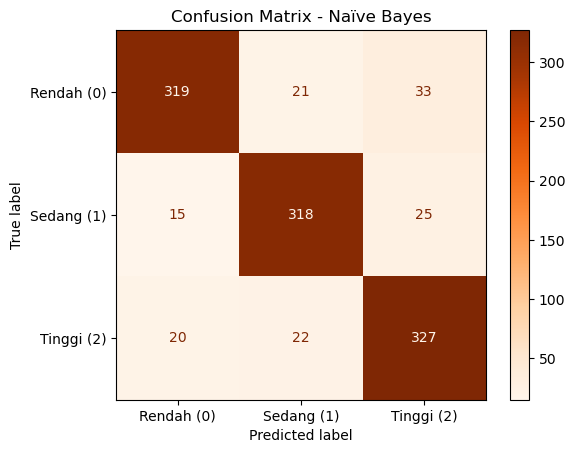


 HASIL EVALUASI CROSS-VALIDATION (URUT F1-SCORE TERTINGGI): Decision Tree
 [Macro F1-Score: 87.55%]
              precision    recall  f1-score   support

  Rendah (0)       0.88      0.87      0.87       373
  Sedang (1)       0.88      0.88      0.88       358
  Tinggi (2)       0.87      0.87      0.87       369

    accuracy                           0.88      1100
   macro avg       0.88      0.88      0.88      1100
weighted avg       0.88      0.88      0.88      1100

--> Rata-rata Confidence Prediksi BENAR : 100.00%
--> Rata-rata Confidence Prediksi SALAH : 100.00%



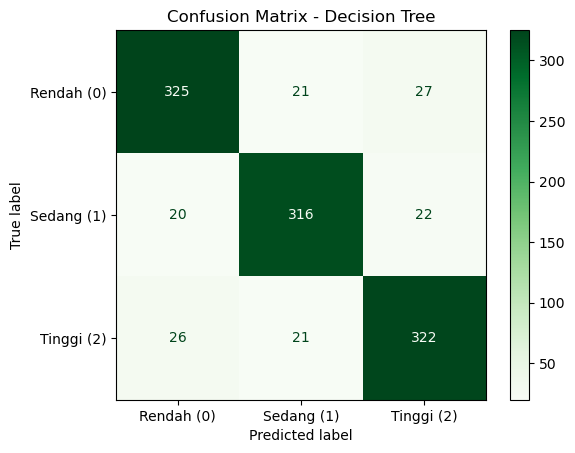


 HASIL EVALUASI CROSS-VALIDATION (URUT F1-SCORE TERTINGGI): K-Nearest Neighbors (KNN)
 [Macro F1-Score: 87.40%]
              precision    recall  f1-score   support

  Rendah (0)       0.94      0.84      0.88       373
  Sedang (1)       0.80      0.92      0.86       358
  Tinggi (2)       0.90      0.86      0.88       369

    accuracy                           0.87      1100
   macro avg       0.88      0.87      0.87      1100
weighted avg       0.88      0.87      0.87      1100

--> Rata-rata Confidence Prediksi BENAR : 97.51%
--> Rata-rata Confidence Prediksi SALAH : 66.41%



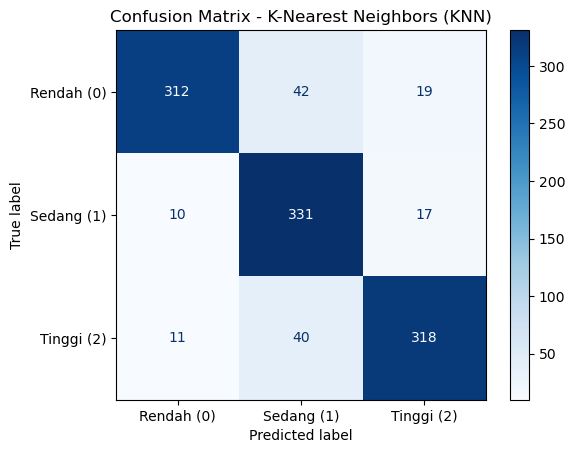

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

# Inisialisasi daftar model awal
model_init = {
    'Naïve Bayes': best_nb_model,
    'K-Nearest Neighbors (KNN)': best_knn_model,
    'Decision Tree': best_dt_model
}

target_names = ['Rendah (0)', 'Sedang (1)', 'Tinggi (2)']

# 1. Lakukan prediksi awal di balik layar untuk menghitung skor F1 makro sebagai dasar pengurutan
model_f1_scores = {}
for nama_model, model in model_init.items():
    y_pred_temp = cross_val_predict(model, X_scaled, y, cv=skf)
    # Menggunakan f1_score dengan rata-rata 'macro' agar adil bagi semua kelas target
    score = f1_score(y, y_pred_temp, average='macro')
    model_f1_scores[nama_model] = score

# 2. Urutkan daftar model berdasarkan nilai F1-Score tertinggi (descending)
daftar_model_urut = sorted(model_init.items(), key=lambda x: model_f1_scores[x[0]], reverse=True)

# 3. Lakukan loop evaluasi berdasarkan urutan model terbaik
for nama_model, model in daftar_model_urut:
    print("\n" + "="*60)
    print(f" HASIL EVALUASI CROSS-VALIDATION (URUT F1-SCORE TERTINGGI): {nama_model}")
    print(f" [Macro F1-Score: {model_f1_scores[nama_model]*100:.2f}%]")
    print("="*60)
    
    # Prediksi menggunakan Stratified K-Fold murni
    y_pred = cross_val_predict(model, X_scaled, y, cv=skf)
    
    # Probabilitas untuk confidence score
    y_proba = cross_val_predict(model, X_scaled, y, cv=skf, method='predict_proba')
    confidence = np.max(y_proba, axis=1)
    
    # Perhitungan rata-rata confidence (Sesuai parameter Bab 3.6 di panduan)
    conf_benar = np.mean(confidence[y_pred == y]) * 100
    conf_salah = np.mean(confidence[y_pred != y]) * 100 if len(confidence[y_pred != y]) > 0 else 0

    print(classification_report(y, y_pred, target_names=target_names))
    print(f"--> Rata-rata Confidence Prediksi BENAR : {conf_benar:.2f}%")
    print(f"--> Rata-rata Confidence Prediksi SALAH : {conf_salah:.2f}%\n")
    
    # Plot Confusion Matrix untuk Error Analysis
    cm = confusion_matrix(y, y_pred)
    cmap_color = 'Oranges' if nama_model == 'Naïve Bayes' else ('Blues' if nama_model == 'K-Nearest Neighbors (KNN)' else 'Greens')
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
    disp.plot(cmap=cmap_color)
    plt.title(f"Confusion Matrix - {nama_model}")
    plt.grid(False)
    plt.show()

#### 5.2 Kesimpulan dan Analisis Kesalahan (Error Analysis)

Berdasarkan hasil pengujian final menggunakan skema Stratified 5-Fold Cross Validation, diperoleh analisis mendalam mengenai karakteristik galat (error) dan tingkat keyakinan (Confidence Score) dari ketiga model sebagai berikut:

#### Karakteristik Tingkat Keyakinan (Confidence Score) Model: 

- `Naïve Bayes`: Model ini mencatatkan rata-rata Confidence Score sebesar 99.42% saat prediksi BENAR, namun tetap bertahan tinggi di angka 90.17% saat prediksi SALAH. Secara fisis, sifat "Naïve" yang mengalikan probabilitas setiap fitur secara terpisah membuat model ini terlalu percaya diri mengakumulasikan peluang, sehingga tetap mengeluarkan estimasi probabilitas tinggi meskipun tebakannya meleset akibat adanya data mahasiswa yang menyimpang (outlier).

- `Decision Tree` : Model ini menghasilkan nilai Confidence Score 100.00% baik saat prediksi BENAR maupun SALAH. Hal ini dikarenakan parameter optimal yang terpilih adalah max_depth: None (pohon tumbuh tanpa batas kedalaman), sehingga setiap ujung daun (leaf node) hanya berisi satu kelas murni. Akibatnya, model langsung memberikan keputusan probabilitas mutlak tanpa ruang keraguan.

- `K-Nearest Neighbors (KNN)` : KNN menjadi model paling realistis karena keyakinannya didasarkan pada voting tetangga ($K=7$). Saat prediksi BENAR, tingkat keyakinannya mencapai 97.51%, namun saat terjadi salah tebak, tingkat keyakinannya langsung drop drastis ke angka 66.41%. Ini membuktikan bahwa KNN sangat sensitif dalam mendeteksi area data yang kabur.

#### Karakteristik Galat Spesifik Per Kelas Target:
Through visualisasi Confusion Matrix, ditemukan bahwa letak kesalahan terbesar terkonsentrasi pada Kelas Sedang (1), terutama pada model KNN di mana nilai Precision jatuh ke angka 0.80 (walau Recall mencapai 0.92). Secara geometri, mahasiswa dengan tingkat stres sedang memiliki profil fitur yang terjepit di tengah-tengah antara kelas Rendah (0) dan Tinggi (2). Karena KNN bekerja murni berdasarkan jarak Euclidean, kedekatan tetangga di zona perbatasan yang padat ini memicu terjadinya bias jarak. Sebaliknya, pendekatan distribusi probabilitas Gaussian pada Naïve Bayes lebih tangguh meredam tumpang tindih tersebut sehingga menghasilkan performa yang jauh lebih seimbang di semua kelas (merata di angka 0.85 - 0.90).

### 5.3 Kesimpulan Akhir (Pemilihan Model Terbaik)
Dari seluruh rangkaian eksperimen yang telah dilakukan pada dataset tingkat stres mahasiswa, dapat ditarik beberapa kesimpulan penting sebagai berikut:

- Ketiga model menunjukkan performa yang sangat luar biasa dan bersaing ketat dengan skor Macro F1-Score berada di kisaran 87%. Hal ini membuktikan bahwa tahapan pra-pemrosesan seperti pemangkasan fitur tidak relevan (korelasi $< 0.6$) dan standardisasi skala (StandardScaler) berhasil membuang noise dan meningkatkan keandalan data.
  
- Proses pencarian parameter menggunakan GridSearchCV yang digabung dengan Stratified 5-Fold Cross Validation terbukti efektif memitigasi risiko overfitting, sehingga performa yang dihasilkan mencerminkan kemampuan generalisasi model yang sesungguhnya.

  
- Secara komparatif, kelompok kami menetapkan Naïve Bayes (Gaussian) dengan parameter var_smoothing: 1e-09 sebagai Model Terbaik Utama. Selain mencatatkan skor tertinggi (87.65%), Naïve Bayes dipilih karena memiliki kesalahan prediksi yang paling seimbang di setiap kelas target, serta memiliki efisiensi komputasi yang jauh lebih ringan dan stabil untuk jangka panjang dibandingkan Decision Tree yang strukturnya harus dipaksa tumbuh tanpa batas (max_depth: None).